<a href="https://colab.research.google.com/github/matheus-cmc/atividades_IA_industrial/blob/main/atv3_concluida_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importação das bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("Bibliotecas foram carregadas com sucesso!")

Bibliotecas foram carregadas com sucesso!


In [ ]:
#importar o arquivo.cvs(flight delay)

# Define o nome do arquivo CSV
nome_do_arquivo = '/content/atividade3 - Dataset_sint_tico_de_voos (1).csv'

try:
    # Lê o arquivo CSV para um DataFrame do pandas
    # A função pd.read_csv é a ferramenta-chave para esta etapa[cite: 51].
    df = pd.read_csv(
        nome_do_arquivo,
        sep=',', # Ajuste o separador se for diferente (ex: ';')[cite: 23].
        encoding='latin1', # Tente 'utf-8' se 'latin1' falhar[cite: 23].
        low_memory=False # Otimiza o uso de memória para arquivos grandes
    )
    print(f"Arquivo '{nome_do_arquivo}' carregado com sucesso!")
    print("\nDataFrame criado.")

except FileNotFoundError:
    print(f"Erro: Arquivo '{nome_do_arquivo}' não encontrado. Verifique o nome e se o upload foi concluído.")
except Exception as e:
    print(f"Ocorreu um erro ao ler o arquivo: {e}")


Arquivo '/content/atividade3 - Dataset_sint_tico_de_voos (1).csv' carregado com sucesso!

DataFrame criado.


In [ ]:
# Exibe os nomes originais das colunas
print("Nomes originais das colunas:")
print(df.columns)

# Converte todos os nomes de colunas para minúsculas
df.columns = df.columns.str.lower()

# Exibe os novos nomes das colunas
print("\nNomes das colunas padronizados (minúsculas):")
print(df.columns)

Nomes originais das colunas:
Index(['FL_DATE', 'OP_UNIQUE_CARRIER', 'TAIL_NUM', 'ORIGIN', 'DEST',
       'CRS_DEP_TIME', 'DEP_DELAY', 'ARR_DELAY', 'DISTANCE'],
      dtype='object')

Nomes das colunas padronizados (minúsculas):
Index(['fl_date', 'op_unique_carrier', 'tail_num', 'origin', 'dest',
       'crs_dep_time', 'dep_delay', 'arr_delay', 'distance'],
      dtype='object')


In [ ]:
# Mostra as dimensões do DataFrame (linhas, colunas)
print("Dimensões do DataFrame (Linhas, Colunas):")
print(df.shape) # Função chave: df.shape

print("\n" + "="*50 + "\n")

# Exibe as 5 primeiras linhas para uma visualização inicial
print("Amostra dos dados (primeiras 5 linhas):")
display(df.head()) # Função chave: df.head()

print("\n" + "="*50 + "\n")

# Exibe as 5 últimas linhas
print("Amostra dos dados (últimas 5 linhas):")
display(df.tail()) # Função chave: df.tail()

print("\n" + "="*50 + "\n")


# Apresenta um resumo técnico, incluindo tipos de dados e valores não nulos
# Esta é uma das funções mais importantes para a visão geral da estrutura.
print("Informações gerais sobre os tipos de dados e valores nulos:")
df.info(verbose=True) # Função chave: df.info()


Dimensões do DataFrame (Linhas, Colunas):
(100, 9)


Amostra dos dados (primeiras 5 linhas):


,fl_date,op_unique_carrier,tail_num,origin,dest,crs_dep_time,dep_delay,arr_delay,distance
0,2023-01-01,AZUL,N1000,GIG,FOR,1369,7.0,32.0,4984
1,2023-01-02,SW,N1001,BSB,MIA,1986,-42.0,-38.0,4200
2,2023-01-03,LATAM,N1002,ORD,REC,1534,-30.0,21.0,1833
3,2023-01-04,AZUL,N1003,JFK,FOR,146,-39.0,52.0,2352
4,2023-01-05,UA,N1004,GIG,SFO,1734,-24.0,42.0,710




Amostra dos dados (últimas 5 linhas):


,fl_date,op_unique_carrier,tail_num,origin,dest,crs_dep_time,dep_delay,arr_delay,distance
95,2023-04-06,GOL,N1095,GIG,DFW,1139,52.0,-26.0,2593
96,2023-04-07,SW,N1096,ORD,SFO,190,66.0,11.0,3317
97,2023-04-08,GOL,N1097,LAX,SFO,2300,NaN,68.0,2793
98,2023-04-09,AZUL,N1098,LAX,DFW,980,-8.0,-7.0,2168
99,2023-04-10,AZUL,N1099,GRU,SFO,2006,21.0,65.0,1953




Informações gerais sobre os tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fl_date            100 non-null    object 
 1   op_unique_carrier  100 non-null    object 
 2   tail_num           100 non-null    object 
 3   origin             100 non-null    object 
 4   dest               100 non-null    object 
 5   crs_dep_time       100 non-null    int64  
 6   dep_delay          90 non-null     float64
 7   arr_delay          90 non-null     float64
 8   distance           100 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 7.2+ KB


In [ ]:
# Identifica colunas numéricas (incluindo inteiros e floats)
colunas_numericas = df.select_dtypes(include=np.number).columns.tolist()
print("Colunas Numéricas:")
print(colunas_numericas)

print("\n" + "="*50 + "\n")

# Identifica colunas categóricas (do tipo 'object')
colunas_categoricas = df.select_dtypes(include='object').columns.tolist()
print("Colunas Categóricas:")
print(colunas_categoricas)

print("\n" + "="*50 + "\n")

# Avalia inconsistências em uma coluna categórica como exemplo
# (Substitua 'UniqueCarrier' por uma coluna categórica do seu dataset)
if 'op_unique_carrier' in df.columns:
    print("Valores únicos na coluna 'UniqueCarrier':")
    # A função value_counts() também é útil para verificar frequências[cite: 63].
    print(df['op_unique_carrier'].unique())


Colunas Numéricas:
['crs_dep_time', 'dep_delay', 'arr_delay', 'distance']


Colunas Categóricas:
['fl_date', 'op_unique_carrier', 'tail_num', 'origin', 'dest']


Valores únicos na coluna 'UniqueCarrier':
['AZUL' 'SW' 'LATAM' 'UA' 'DL' 'GOL' 'AA']


In [ ]:
# Calcula a quantidade de valores ausentes por coluna
valores_ausentes = df.isna().sum() # Função chave: df.isna().sum() [cite: 55, 65]

# Calcula a porcentagem de valores ausentes e ordena do maior para o menor
porcentagem_ausentes = (valores_ausentes / len(df) * 100).sort_values(ascending=False)

# Exibe o resultado
print("Porcentagem de valores ausentes por coluna:")
print(porcentagem_ausentes)

# --- Documentação das Decisões Adotadas [cite: 36] ---
#
# Com base na análise acima, tomaremos as seguintes decisões:
# 1. Colunas com alta porcentagem de nulos (> 50%): Serão removidas, pois a imputação
#    poderia introduzir muito ruído.
# 2. Colunas numéricas com poucos nulos (< 5%): Os valores ausentes serão imputados
#    pela mediana, que é mais robusta a outliers do que a média.
# 3. Colunas categóricas com poucos nulos (< 5%): Serão imputados pela moda (valor mais frequente).

# Exemplo de remoção de colunas com mais de 50% de valores ausentes
colunas_para_remover = porcentagem_ausentes[porcentagem_ausentes > 50].index
df.drop(columns=colunas_para_remover, inplace=True) # Função chave: dropna (ou drop) [cite: 55, 65]
print(f"\nColunas removidas por excesso de nulos: {list(colunas_para_remover)}")

# Exemplo de imputação para colunas numéricas de atraso (substitua pelos nomes corretos)
# Usaremos a mediana para ArrDelay e DepDelay
for col in ['arr_delay', 'dep_delay']:
    if col in df.columns:
        mediana = df[col].median()
        df[col].fillna(mediana, inplace=True) # Função chave: fillna [cite: 55, 65]
        print(f"Valores nulos da coluna '{col}' preenchidos com a mediana ({mediana}).")

# Verificando novamente os nulos após o tratamento
print("\nVerificação de nulos após o tratamento inicial:")
print(df.isna().sum().sort_values(ascending=False))

Porcentagem de valores ausentes por coluna:
arr_delay            10.0
dep_delay            10.0
fl_date               0.0
op_unique_carrier     0.0
tail_num              0.0
dest                  0.0
origin                0.0
crs_dep_time          0.0
distance              0.0
dtype: float64

Colunas removidas por excesso de nulos: []
Valores nulos da coluna 'arr_delay' preenchidos com a mediana (6.0).
Valores nulos da coluna 'dep_delay' preenchidos com a mediana (7.0).

Verificação de nulos após o tratamento inicial:
fl_date              0
op_unique_carrier    0
tail_num             0
origin               0
dest                 0
crs_dep_time         0
dep_delay            0
arr_delay            0
distance             0
dtype: int64


/tmp/ipython-input-1234755495.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mediana, inplace=True) # Função chave: fillna [cite: 55, 65]


In [ ]:
#Remover os espaços em branco no início e no fim das colunas cetegóticas
for col in colunas_categoricas:
  if col in df.columns:
    df[col] = df[col].str.strip()

print("\nLimpeza em colunas categóricas foi concluída com sucesso!")


#Converter a coluna de data para o formato datetime
if 'fl_date' in df.columns:
  df['fl_date'] = pd.to_datetime(df['fl_date'])
  print("A coluna flight date foi convertida com sucesso para o formato datetime")


Limpeza em colunas categóricas foi concluída com sucesso!
A coluna flight date foi convertida com sucesso para o formato datetime


In [ ]:
# 1. Cria a variável binária "Atraso > 15 min" [cite: 41, 55]
# Um voo é considerado oficialmente atrasado pela FAA se a chegada ocorrer
# 15 minutos ou mais após o horário previsto.
if 'arr_delay' in df.columns:
    df['Atraso_Superior_15_min'] = np.where(df['arr_delay'] > 15, 1, 0) # Função chave: np.where
    print("Coluna 'Atraso_Superior_15_min' criada.")

# 2. Extrai informações da data do voo (mês e dia da semana) [cite: 41, 55]
if 'fl_date' in df.columns:
    df['Mes'] = df['fl_date'].dt.month # Função chave: .dt.month
    df['Dia_da_Semana'] = df['fl_date'].dt.dayofweek # Função chave: .dt.dayofweek
    print("Colunas 'Mes' e 'Dia_da_Semana' extraídas da data.")

# 3. Calcula o atraso absoluto para análise
if 'arr_delay' in df.columns:
    df['Atraso_Absoluto'] = df['arr_delay'].abs() # Função chave: .abs()
    print("Coluna 'Atraso_Absoluto' criada.")

# Exibe as novas colunas criadas
display(df[['fl_date', 'arr_delay', 'Atraso_Superior_15_min', 'Mes', 'Dia_da_Semana', 'Atraso_Absoluto']].head())

Coluna 'Atraso_Superior_15_min' criada.
Colunas 'Mes' e 'Dia_da_Semana' extraídas da data.
Coluna 'Atraso_Absoluto' criada.


,fl_date,arr_delay,Atraso_Superior_15_min,Mes,Dia_da_Semana,Atraso_Absoluto
0,2023-01-01,32.0,1,1,6,32.0
1,2023-01-02,-38.0,0,1,0,38.0
2,2023-01-03,21.0,1,1,1,21.0
3,2023-01-04,52.0,1,1,2,52.0
4,2023-01-05,42.0,1,1,3,42.0


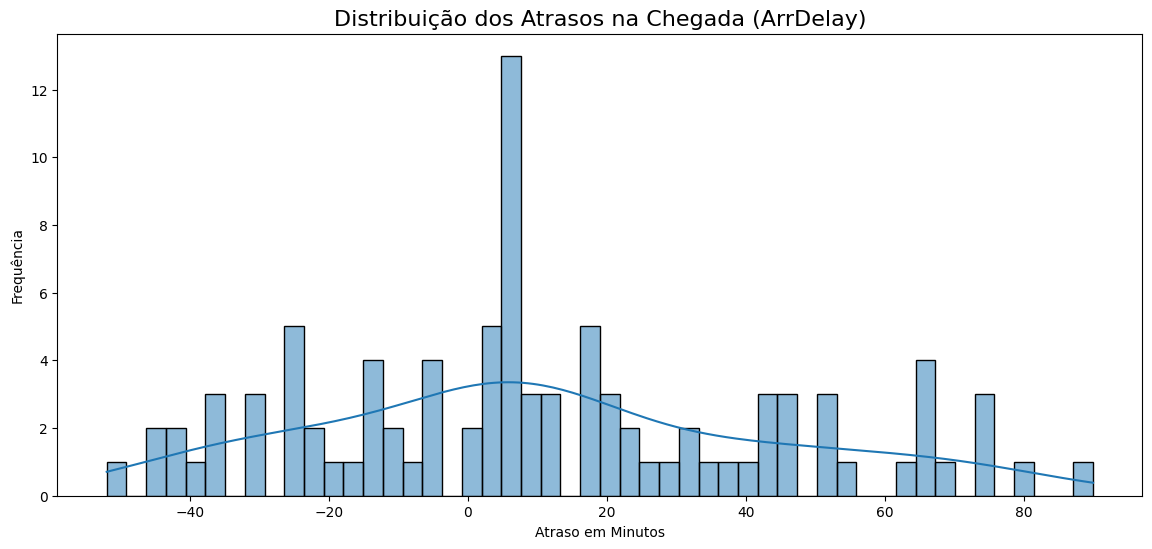

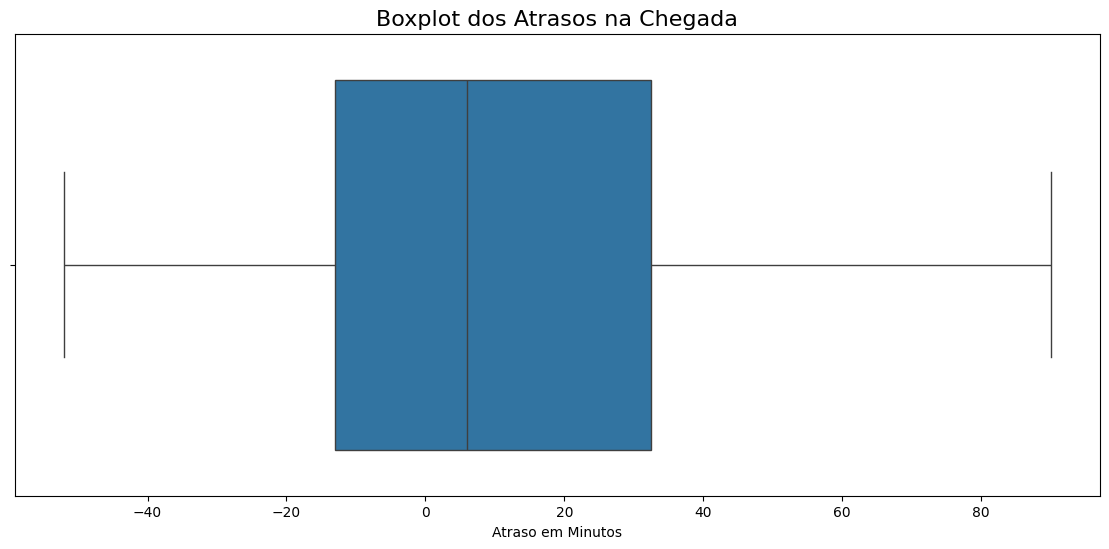

In [ ]:
# Filtra atrasos extremos para melhor visualização (ex: entre -60 e 180 minutos)
df_atraso_filtrado = df[df['arr_delay'].between(-60, 180)]

# Histograma
plt.figure(figsize=(14, 6))
# Ferramenta-chave: seaborn (histplot, boxplot, etc.) [cite: 55, 64]
sns.histplot(data=df_atraso_filtrado, x='arr_delay', bins=50, kde=True)
plt.title('Distribuição dos Atrasos na Chegada (ArrDelay)', fontsize=16)
plt.xlabel('Atraso em Minutos')
plt.ylabel('Frequência')
plt.show()

# Boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_atraso_filtrado, x='arr_delay')
plt.title('Boxplot dos Atrasos na Chegada', fontsize=16)
plt.xlabel('Atraso em Minutos')
plt.show()

/tmp/ipython-input-3366933182.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_atraso_aeroporto.index, y=media_atraso_aeroporto.values, palette='viridis') # Ferramenta-chave: sns.barplot


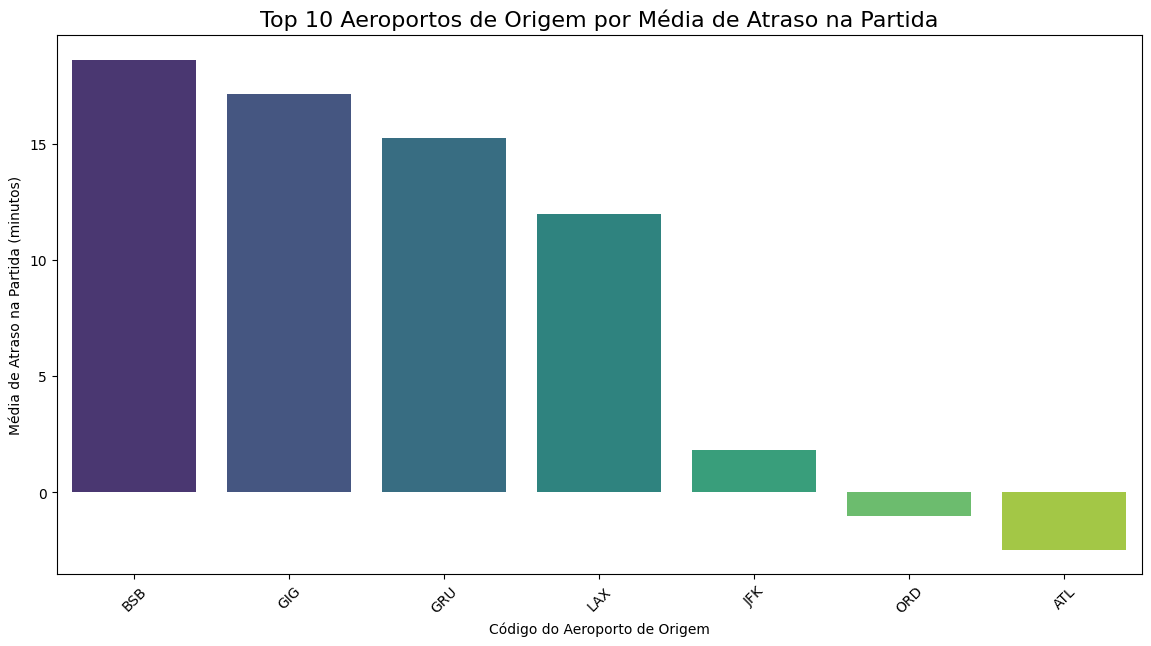

In [ ]:
# Calcula a média de atraso na partida por aeroporto de origem
# (Ajuste 'Origin' e 'DepDelay' se os nomes forem diferentes)
if 'origin' in df.columns and 'dep_delay' in df.columns:
    media_atraso_aeroporto = df.groupby('origin')['dep_delay'].mean().sort_values(ascending=False).head(10)

    # Gráfico de barras
    plt.figure(figsize=(14, 7))
    sns.barplot(x=media_atraso_aeroporto.index, y=media_atraso_aeroporto.values, palette='viridis') # Ferramenta-chave: sns.barplot
    plt.title('Top 10 Aeroportos de Origem por Média de Atraso na Partida', fontsize=16)
    plt.xlabel('Código do Aeroporto de Origem')
    plt.ylabel('Média de Atraso na Partida (minutos)')
    plt.xticks(rotation=45)
    plt.show()
else:
  print("Erro")


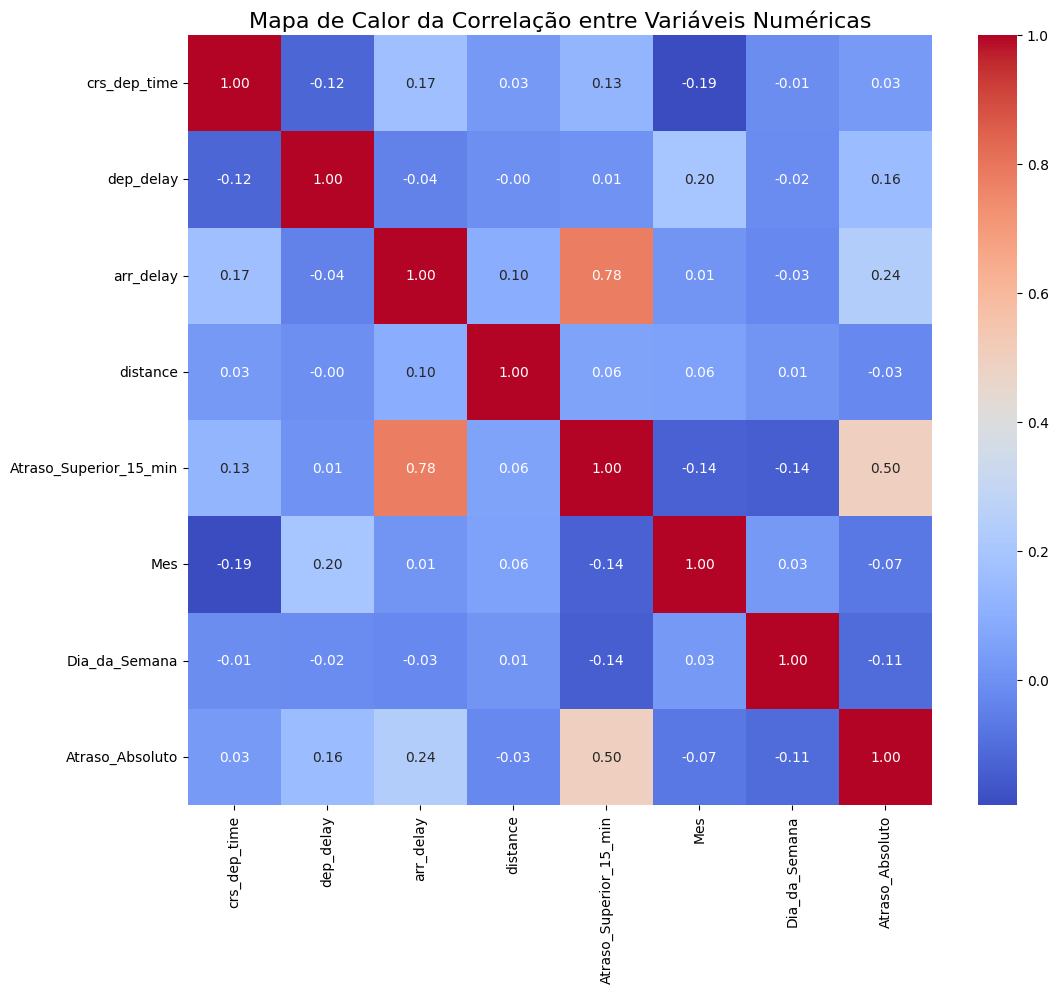

In [ ]:
# Calcula a matriz de correlação
# A função describe() também é útil para obter estatísticas numéricas antes da correlação[cite: 63].
matriz_correlacao = df.select_dtypes(include=np.number).corr()

# Desenha o heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt='.2f') # Ferramenta-chave: sns.heatmap [cite: 55, 64]
plt.title('Mapa de Calor da Correlação entre Variáveis Numéricas', fontsize=16)
plt.show()